# Hierarchical ReLU-LoRA Spawning — Unit Test Notebook

## Purpose
This notebook validates the **mathematical correctness** of the Hierarchical ReLU-LoRA Spawning framework before scaling to the full Phi-mini-MoE model. It is structured in two stages:

- **Stage 1 (Cells 1–7):** Synthetic toy MoE — runs in ~2 minutes on CPU. Validates all three structural checks with zero setup.
- **Stage 2 (Cells 8–12):** Real Phi-3.5-MoE-instruct — requires 24GB VRAM. Only run this after Stage 1 passes cleanly.

### The 3 Pass/Fail Checks
| Check | What it proves | Pass condition |
|-------|---------------|----------------|
| **Check 1** | Bivariate trigger fires at a sensible rate | 5–20 spawns per 1000 steps |
| **Check 2** | Zero-loss guarantee after spawn | `|loss_post - loss_pre| < 0.01` |
| **Check 3** | Dead-zone escape (non-zero gradient) | `grad_norm > 0` on sub-router |

### Known bugs fixed from original pseudocode
1. **Gate shape**: `ReLU(w^T x)` produces `(batch, seq, 1)` — must use `.unsqueeze(-1)` for safe broadcasting against `sub_out` shape `(batch, seq, out_features)`
2. **lora_B_0 must be zero-init** (not kaiming) — standard LoRA: B=0, A=kaiming
3. **SVD must be fp32** — bf16 SVD silently returns NaNs on most hardware
4. **Gradient capture needs a backward hook** on expert OUTPUT, not weight param
5. **`optimizer.add_param_group()` must precede `optimizer.step()`** on the spawn step
6. **Check 3 gradient must be read BEFORE `optimizer.zero_grad()`** — otherwise it's already wiped
7. **`sigma = c * Var(W_k)` not `Std(W_k)`** — use std for correct units (same as W_k)

---
# STAGE 1: Synthetic Toy MoE
### Run this first. It takes 2 minutes and requires no GPU or model download.

In [1]:
# Cell 1: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import deque

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Running on: {DEVICE}')
if DEVICE == 'cuda':
    print(f'VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Running on: cpu


In [2]:
# Cell 2: HierarchicalExpert Module
# This is the core contribution. Read every comment.

class HierarchicalExpert(nn.Module):
    """
    Replaces a single MoE expert's FFN with a hierarchically expandable version.
    
    Forward pass:
        E_k(x) = W_k x + B_0 A_0 x + sum_j [ ReLU(w_j^T x) * B_j A_j x ]
    
    The ReLU gate is INDEPENDENT of the global softmax router.
    Adding sub-adapters has zero effect on other experts' routing probabilities.
    """
    
    def __init__(self, in_features: int, out_features: int, 
                 base_rank: int = 16, lora_alpha: int = 32):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = base_rank
        self.scaling = lora_alpha / base_rank
        
        # Frozen base weights W_k
        self.weight = nn.Parameter(
            torch.empty(out_features, in_features), requires_grad=False
        )
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        
        # Base LoRA adapter L_{k,0}
        # CRITICAL: B=zeros, A=kaiming — standard LoRA initialization
        # B=zeros ensures BA=0 at t=0, preserving function identity
        self.lora_A_0 = nn.Parameter(torch.empty(base_rank, in_features))
        self.lora_B_0 = nn.Parameter(torch.zeros(out_features, base_rank))  # MUST be zero
        nn.init.kaiming_uniform_(self.lora_A_0, a=math.sqrt(5))
        
        # Dynamic sub-adapter storage
        # nn.ParameterList keeps these in the autograd graph
        self.sub_A = nn.ParameterList()
        self.sub_B = nn.ParameterList()
        self.sub_w = nn.ParameterList()  # ReLU gating vectors, shape (1, in_features) each
        
        # For saturation monitoring
        self._output_grad = None  # Set by backward hook
        self._hook_handle = None
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x shape: (batch, seq_len, in_features) or (batch, in_features)
        """
        # Base: W_k x
        base_out = F.linear(x, self.weight)
        
        # Base LoRA: B_0 A_0 x
        lora_0_out = F.linear(F.linear(x, self.lora_A_0), self.lora_B_0) * self.scaling
        
        output = base_out + lora_0_out
        
        # Sub-adapters (empty at init, grows after spawn events)
        for j in range(len(self.sub_w)):
            # Gate: scalar per token
            # sub_w[j] shape: (1, in_features)
            # F.linear(x, sub_w[j]) shape: (batch, seq, 1)
            gate = F.relu(F.linear(x, self.sub_w[j]))  # (batch, seq, 1)
            
            # Sub-adapter output: (batch, seq, out_features)
            sub_out = F.linear(F.linear(x, self.sub_A[j]), self.sub_B[j]) * self.scaling
            
            # BUG FIX: gate is (batch, seq, 1), sub_out is (batch, seq, out_features)
            # Broadcasting works correctly here: each token's scalar gate
            # scales the entire out_features dimension
            output = output + gate * sub_out
            
        return output

    def register_grad_hook(self):
        """Register backward hook to capture dL/d(output) for SVD initialization."""
        def hook(grad):
            # Average over batch and sequence dims, keep feature dims
            self._output_grad = grad.detach().float()
        return hook  # Caller registers this on the output tensor

    @torch.no_grad()
    def spawn_sub_adapter(self, residual_gradient: torch.Tensor):
        """
        Spawns one new sub-adapter when saturation is detected.
        
        Args:
            residual_gradient: dL/d(expert_output), shape (out_features, in_features)
                               after averaging over batch/seq dims.
        """
        device = self.weight.device
        dtype = self.weight.dtype
        
        # ── Step 1: Sub-router initialization ────────────────────────────────
        # sigma = c * std(W_k) — scales noise to the base weight magnitude
        # BUG FIX: use std(), not var() — var has squared units
        c = 1e-4
        sigma = c * self.weight.float().std().item()
        
        new_w = nn.Parameter(
            torch.randn(1, self.in_features, device=device, dtype=dtype) * sigma
        )
        print(f"  [spawn] sigma = {sigma:.2e}, "
              f"w_init_norm = {new_w.data.norm().item():.2e}")
        
        # ── Step 2: LoRA-GA SVD initialization ──────────────────────────────
        # SVD in fp32 to avoid bf16/fp16 NaN issues
        grad_fp32 = residual_gradient.float()
        
        # Handle shape: grad might be (out, in) or (batch, seq, out, in)
        if grad_fp32.dim() > 2:
            grad_fp32 = grad_fp32.mean(dim=tuple(range(grad_fp32.dim() - 2)))
        
        # Clamp rank to valid range
        max_rank = min(self.rank, grad_fp32.shape[0], grad_fp32.shape[1])
        
        try:
            U, S, Vh = torch.linalg.svd(grad_fp32, full_matrices=False)
            # LoRA-GA: A <- V_r^T (right singular vectors), B <- U_r (left)
            new_A = nn.Parameter(Vh[:max_rank, :].to(dtype))   # (rank, in_features)
            new_B = nn.Parameter(U[:, :max_rank].to(dtype))    # (out_features, rank)
            print(f"  [spawn] SVD success, top singular value = {S[0].item():.4f}")
        except Exception as e:
            # Fallback: random init if gradient is degenerate
            print(f"  [spawn] SVD failed ({e}), falling back to random init")
            new_A = nn.Parameter(torch.empty(max_rank, self.in_features, 
                                              device=device, dtype=dtype))
            new_B = nn.Parameter(torch.zeros(self.out_features, max_rank, 
                                              device=device, dtype=dtype))
            nn.init.kaiming_uniform_(new_A, a=math.sqrt(5))
        
        # ── Step 3: Register ────────────────────────────────────────────────
        self.sub_w.append(new_w)
        self.sub_A.append(new_A)
        self.sub_B.append(new_B)
        print(f"  [spawn] Sub-adapter #{len(self.sub_w)} registered.")
        
        return [new_w, new_A, new_B]  # Return params so caller adds to optimizer


print("HierarchicalExpert defined.")

HierarchicalExpert defined.


In [3]:
# Cell 3: Saturation Monitor
# Tracks per-expert EMA of rank importance and residual error ratio.

class SaturationMonitor:
    """
    Tracks the bivariate saturation trigger for one expert:
    
    Trigger fires when, over window W steps:
      1. Learning Plateau: d/dt g_k^(t) < tau_plateau
      2. High Residual Error: L_k^(t) > alpha * L_batch^(t)
    """
    
    def __init__(self, expert_id: int, beta: float = 0.9,
                 window: int = 50, tau_plateau: float = 1e-4,
                 alpha: float = 1.25):
        self.expert_id = expert_id
        self.beta = beta              # EMA decay
        self.window = window          # Sustained steps before triggering
        self.tau_plateau = tau_plateau  # Rank importance plateau threshold
        self.alpha = alpha            # Residual error ratio threshold (must be > 1)
        
        # EMA of rank importance
        self.rank_importance_ema = 0.0
        self.prev_rank_importance_ema = 0.0
        
        # History for window-based detection
        self.plateau_hits = deque(maxlen=window)
        self.error_hits = deque(maxlen=window)
        
        # Logging
        self.history_importance = []
        self.history_ratio = []
        self.has_spawned = False
        
    def compute_rank_importance(self, lora_A: torch.Tensor, lora_B: torch.Tensor,
                                 grad_A: torch.Tensor, grad_B: torch.Tensor) -> float:
        """
        DR-LoRA style rank importance:
        s_j = ||dL/da_j ⊙ a_j||_1 * ||dL/db_j ⊙ b_j||_1
        Averaged over rank dimensions.
        """
        if grad_A is None or grad_B is None:
            return 0.0
        
        total = 0.0
        rank = lora_A.shape[0]
        for j in range(rank):
            a_j = lora_A[j]
            b_j = lora_B[:, j]
            da_j = grad_A[j] if grad_A is not None else torch.zeros_like(a_j)
            db_j = grad_B[:, j] if grad_B is not None else torch.zeros_like(b_j)
            
            score_a = (da_j * a_j).abs().sum().item()
            score_b = (db_j * b_j).abs().sum().item()
            total += score_a * score_b
        
        return total / rank
    
    def update(self, lora_A: torch.Tensor, lora_B: torch.Tensor,
               expert_loss: float, batch_loss: float,
               grad_A=None, grad_B=None) -> bool:
        """
        Update monitor state. Returns True if spawn should be triggered.
        """
        if self.has_spawned:
            return False  # Don't re-trigger immediately after a spawn
        
        # ── Compute rank importance ──────────────────────────────────────────
        raw_importance = self.compute_rank_importance(
            lora_A.detach(), lora_B.detach(), grad_A, grad_B
        )
        self.prev_rank_importance_ema = self.rank_importance_ema
        self.rank_importance_ema = (self.beta * self.rank_importance_ema + 
                                     (1 - self.beta) * raw_importance)
        
        # ── Check 1: Learning plateau ────────────────────────────────────────
        importance_delta = abs(self.rank_importance_ema - self.prev_rank_importance_ema)
        plateau = importance_delta < self.tau_plateau
        self.plateau_hits.append(plateau)
        
        # ── Check 2: High residual error ─────────────────────────────────────
        ratio = expert_loss / (batch_loss + 1e-8)  # avoid div by zero
        high_error = ratio > self.alpha
        self.error_hits.append(high_error)
        
        # ── Log ──────────────────────────────────────────────────────────────
        self.history_importance.append(self.rank_importance_ema)
        self.history_ratio.append(ratio)
        
        # ── Trigger: both conditions sustained over full window ──────────────
        if (len(self.plateau_hits) == self.window and 
            all(self.plateau_hits) and all(self.error_hits)):
            return True
        
        return False
    
    def reset_after_spawn(self):
        """Reset window after spawn to prevent immediate re-triggering."""
        self.plateau_hits.clear()
        self.error_hits.clear()
        self.has_spawned = True  # Set False manually if you want multiple spawns


print("SaturationMonitor defined.")

SaturationMonitor defined.


In [4]:
# Cell 4: Toy MoE model
# This is a minimal MoE that mimics the structure of Phi-mini-MoE
# without requiring any model downloads.
# Replace this with the real model in Stage 2.

class ToyTopKRouter(nn.Module):
    def __init__(self, hidden: int, n_experts: int, top_k: int = 2):
        super().__init__()
        self.gate = nn.Linear(hidden, n_experts, bias=False)
        self.top_k = top_k
        self.n_experts = n_experts
        
    def forward(self, x):
        # x: (batch, seq, hidden)
        logits = self.gate(x)  # (batch, seq, n_experts)
        scores = torch.softmax(logits, dim=-1)
        top_scores, top_idx = torch.topk(scores, self.top_k, dim=-1)
        # Renormalize top-k
        top_scores = top_scores / top_scores.sum(dim=-1, keepdim=True)
        return top_scores, top_idx


class ToyMoELayer(nn.Module):
    """Minimal MoE with one HierarchicalExpert (expert 0) and N-1 standard experts."""
    
    def __init__(self, hidden: int, ffn_dim: int, n_experts: int = 4, 
                 top_k: int = 2, base_rank: int = 8):
        super().__init__()
        self.hidden = hidden
        self.n_experts = n_experts
        self.top_k = top_k
        
        # Frozen router
        self.router = ToyTopKRouter(hidden, n_experts, top_k)
        for p in self.router.parameters():
            p.requires_grad = False
        
        # Expert 0: our HierarchicalExpert (the one being monitored)
        self.hierarchical_expert = HierarchicalExpert(
            hidden, ffn_dim, base_rank=base_rank
        )
        # Experts 1..N-1: standard frozen FFNs
        self.standard_experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, ffn_dim, bias=False),
                nn.GELU(),
                nn.Linear(ffn_dim, hidden, bias=False)
            ) for _ in range(n_experts - 1)
        ])
        # Freeze standard experts
        for expert in self.standard_experts:
            for p in expert.parameters():
                p.requires_grad = False
    
    def forward(self, x):
        # x: (batch, seq, hidden)
        batch, seq, hidden = x.shape
        top_scores, top_idx = self.router(x)  # both: (batch, seq, top_k)
        
        output = torch.zeros_like(x)
        
        for k in range(self.top_k):
            expert_ids = top_idx[:, :, k]   # (batch, seq)
            weights = top_scores[:, :, k]   # (batch, seq)
            
            # Process each expert
            for e_id in range(self.n_experts):
                mask = (expert_ids == e_id)  # (batch, seq) bool
                if not mask.any():
                    continue
                
                # Gather tokens for this expert
                tokens = x[mask]  # (n_selected, hidden)
                w = weights[mask].unsqueeze(-1)  # (n_selected, 1)
                
                if e_id == 0:
                    expert_out = self.hierarchical_expert(tokens)
                else:
                    expert_out = self.standard_experts[e_id - 1](tokens)
                
                output[mask] += w * expert_out[:, :hidden]  # trim if ffn_dim != hidden
        
        return output


class ToyModel(nn.Module):
    def __init__(self, vocab: int = 1000, hidden: int = 128, 
                 ffn_dim: int = 256, n_experts: int = 4):
        super().__init__()
        self.embed = nn.Embedding(vocab, hidden)
        self.moe_layer = ToyMoELayer(hidden, ffn_dim, n_experts=n_experts)
        self.norm = nn.LayerNorm(hidden)
        self.lm_head = nn.Linear(hidden, vocab, bias=False)
    
    def forward(self, input_ids):
        x = self.embed(input_ids)       # (batch, seq, hidden)
        x = self.moe_layer(x)           # (batch, seq, hidden)
        x = self.norm(x)
        logits = self.lm_head(x)        # (batch, seq, vocab)
        return logits


print("Toy MoE model defined.")

Toy MoE model defined.


In [5]:
# Cell 5: Forced-Collision Micro-Dataset
# In the toy setting: two token distributions = two 'domains'
# Domain A (Code): token IDs in range [0, 499]
# Domain B (Medical): token IDs in range [500, 999]
# We force the model to see them in alternating batches to maximise gradient conflict.

def make_micro_dataset(vocab: int = 1000, seq_len: int = 32, 
                        n_examples: int = 100, seed: int = 42):
    """
    Creates 50 'code' sequences and 50 'medical' sequences.
    Code tokens: [0, vocab//2)
    Medical tokens: [vocab//2, vocab)
    """
    torch.manual_seed(seed)
    half = n_examples // 2
    
    # Code sequences: token ids from lower half of vocabulary
    code_seqs = torch.randint(0, vocab // 2, (half, seq_len))
    code_labels = torch.roll(code_seqs, -1, dims=1)  # next-token prediction
    
    # Medical sequences: token ids from upper half
    med_seqs = torch.randint(vocab // 2, vocab, (half, seq_len))
    med_labels = torch.roll(med_seqs, -1, dims=1)
    
    all_seqs = torch.cat([code_seqs, med_seqs], dim=0)
    all_labels = torch.cat([code_labels, med_labels], dim=0)
    
    # Shuffle aggressively so code/medical alternate
    perm = torch.randperm(n_examples)
    return all_seqs[perm], all_labels[perm]


VOCAB = 1000
SEQ_LEN = 32
seqs, labels = make_micro_dataset(vocab=VOCAB, seq_len=SEQ_LEN)
print(f"Dataset: {seqs.shape[0]} sequences of length {SEQ_LEN}")
print(f"First 5 first-tokens: {seqs[:5, 0].tolist()} (< 500 = code, >= 500 = medical)")

Dataset: 100 sequences of length 32
First 5 first-tokens: [932, 174, 872, 356, 755] (< 500 = code, >= 500 = medical)


In [6]:
# Cell 6: Gradient Hook Utility
# We need to capture dL/d(expert_output) at the OUTPUT TENSOR level,
# not at the weight parameter level.
# This is the correct way to get the residual gradient for LoRA-GA SVD.

class GradientCapture:
    """
    Registers a hook on a tensor to capture its gradient during backprop.
    
    Usage:
        capture = GradientCapture()
        output = expert(x)
        capture.register(output)  # Register on output tensor
        loss.backward()
        grad = capture.get()  # Now has dL/d(output)
    """
    def __init__(self):
        self._grad = None
        self._handle = None
    
    def register(self, tensor: torch.Tensor):
        if self._handle is not None:
            self._handle.remove()
        def hook(grad):
            self._grad = grad.detach().clone()
        self._handle = tensor.register_hook(hook)
    
    def get(self) -> torch.Tensor:
        return self._grad
    
    def clear(self):
        self._grad = None
    
    def remove(self):
        if self._handle is not None:
            self._handle.remove()


def compute_expert_loss_mask(logits, labels, expert_mask, criterion):
    """
    Compute loss only for tokens that were routed to a specific expert.
    
    In practice, expert routing info must be surfaced from the MoE layer.
    For the toy model, we use domain membership as a proxy.
    
    expert_mask: bool tensor (batch, seq) — True for tokens in this expert
    """
    if not expert_mask.any():
        return torch.tensor(0.0, device=logits.device)
    
    # Flatten
    flat_logits = logits.view(-1, logits.shape[-1])   # (batch*seq, vocab)
    flat_labels = labels.view(-1)                       # (batch*seq,)
    flat_mask = expert_mask.view(-1)                    # (batch*seq,)
    
    masked_logits = flat_logits[flat_mask]
    masked_labels = flat_labels[flat_mask]
    
    return criterion(masked_logits, masked_labels)


print("Gradient capture utilities defined.")

Gradient capture utilities defined.


In [7]:
# Cell 7: Main Training Loop — Stage 1 (Toy Model)
# This is the full unit test. Watch for PASS/FAIL printouts.

torch.manual_seed(42)

# ── Hyperparameters ──────────────────────────────────────────────────────────
# Trigger hyperparams — calibrate here in the toy before locking for real model
WINDOW          = 20        # Steps before trigger fires (toy: small for speed)
TAU_PLATEAU     = 1e-5      # Rank importance plateau sensitivity
ALPHA           = 1.2       # Residual error ratio (1.2 = 20% above batch average)
LR              = 5e-4
N_STEPS         = 300
BATCH_SIZE      = 4

# ── Model ────────────────────────────────────────────────────────────────────
model = ToyModel(vocab=VOCAB, hidden=128, ffn_dim=256, n_experts=4).to(DEVICE)
expert = model.moe_layer.hierarchical_expert

# Only train the LoRA parameters (base weights are already frozen)
trainable_params = [p for p in expert.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR)
criterion = nn.CrossEntropyLoss()

# ── Monitor and gradient capture ─────────────────────────────────────────────
monitor = SaturationMonitor(
    expert_id=0, 
    window=WINDOW,
    tau_plateau=TAU_PLATEAU,
    alpha=ALPHA
)
grad_capture = GradientCapture()

# ── Logging ──────────────────────────────────────────────────────────────────
loss_log = []
spawn_steps = []
spawn_pre_loss = None
check2_passed = None
check3_passed = None
check1_passed = False

print(f"Training for {N_STEPS} steps...")
print(f"  Trigger window={WINDOW}, tau={TAU_PLATEAU}, alpha={ALPHA}")
print(f"  Monitoring Expert 0 (HierarchicalExpert)")
print("-" * 60)

seqs_dev = seqs.to(DEVICE)
labels_dev = labels.to(DEVICE)

for step in range(N_STEPS):
    # ── Sample batch ────────────────────────────────────────────────────────
    idx = torch.randint(0, len(seqs_dev), (BATCH_SIZE,))
    batch_x = seqs_dev[idx]       # (batch, seq)
    batch_y = labels_dev[idx]     # (batch, seq)
    
    optimizer.zero_grad()
    
    # ── Forward pass with gradient hook on expert output ─────────────────────
    # We need to hook the expert's output inside the forward pass
    # Use a forward hook on the expert module itself
    expert_output_ref = []
    
    def capture_expert_output(module, input, output):
        # output: (n_selected, out_features)
        # Register grad hook on the output tensor
        if output.requires_grad:
            grad_capture.register(output)
        expert_output_ref.append(output)
    
    hook_handle = expert.register_forward_hook(capture_expert_output)
    
    logits = model(batch_x)  # (batch, seq, vocab)
    hook_handle.remove()
    
    # ── Compute losses ────────────────────────────────────────────────────────
    # Overall batch loss
    batch_loss = criterion(logits.view(-1, VOCAB), batch_y.view(-1))
    
    # Expert-specific loss proxy: use domain label as routing proxy
    # In real model, you'd use actual routing masks from the MoE layer
    domain_mask = (batch_x >= VOCAB // 2)  # True for 'medical' tokens
    expert_loss_val = compute_expert_loss_mask(
        logits, batch_y, domain_mask, criterion
    )
    
    loss_log.append(batch_loss.item())
    
    # ── Backward ─────────────────────────────────────────────────────────────
    batch_loss.backward()
    
    # ── Saturation monitor update ─────────────────────────────────────────────
    grad_A = expert.lora_A_0.grad
    grad_B = expert.lora_B_0.grad
    
    trigger = monitor.update(
        lora_A=expert.lora_A_0.data,
        lora_B=expert.lora_B_0.data,
        expert_loss=expert_loss_val.item(),
        batch_loss=batch_loss.item(),
        grad_A=grad_A,
        grad_B=grad_B
    )
    
    # ── CHECK 1: Trigger fires? ───────────────────────────────────────────────
    if trigger and not check1_passed:
        check1_passed = True
        spawn_steps.append(step)
        print(f"\n✅ CHECK 1 PASS — SPAWN TRIGGERED at step {step}")
        print(f"   Rank importance EMA : {monitor.rank_importance_ema:.2e}")
        print(f"   Residual error ratio: {monitor.history_ratio[-1]:.3f} (threshold: {ALPHA})")
        
        # ── CHECK 2: Zero-loss guarantee ─────────────────────────────────────
        spawn_pre_loss = batch_loss.item()
        
        # Get residual gradient for SVD
        captured_grad = grad_capture.get()
        if captured_grad is None:
            print("  ⚠️  No gradient captured — using lora_A grad as fallback")
            captured_grad = (grad_A if grad_A is not None 
                             else torch.randn(expert.out_features, expert.in_features))
        
        # Average over any extra dims to get (out_features, in_features)
        if captured_grad.dim() > 2:
            captured_grad = captured_grad.reshape(-1, captured_grad.shape[-1])
        
        print(f"\n   Running Check 2: Zero-Loss Guarantee...")
        print(f"   Loss BEFORE spawn: {spawn_pre_loss:.5f}")
        
        # Spawn the sub-adapter
        new_params = expert.spawn_sub_adapter(captured_grad)
        
        # BUG FIX: add to optimizer BEFORE stepping
        optimizer.add_param_group({'params': new_params, 'lr': LR})
        monitor.reset_after_spawn()
        
        # Re-evaluate SAME batch without optimizer step to measure spawn effect
        with torch.no_grad():
            test_logits = model(batch_x)
            spawn_post_loss = criterion(test_logits.view(-1, VOCAB), batch_y.view(-1)).item()
        
        loss_delta = abs(spawn_post_loss - spawn_pre_loss)
        print(f"   Loss AFTER spawn : {spawn_post_loss:.5f}")
        print(f"   |Δ Loss|          : {loss_delta:.6f}")
        
        if loss_delta < 0.01:
            check2_passed = True
            print(f"✅ CHECK 2 PASS — Loss spike {loss_delta:.6f} < 0.01")
        else:
            check2_passed = False
            print(f"❌ CHECK 2 FAIL — Loss spike {loss_delta:.6f} ≥ 0.01")
            print(f"   Fix: Reduce sigma multiplier c or verify ReLU gate init")
    
    # ── Optimizer step ────────────────────────────────────────────────────────
    optimizer.step()
    
    # ── CHECK 3: Dead zone escape — read grad BEFORE zero_grad ───────────────
    if check1_passed and check3_passed is None and len(expert.sub_w) > 0:
        w_grad = expert.sub_w[-1].grad
        if w_grad is not None:
            grad_norm = w_grad.norm().item()
            print(f"\n   Running Check 3: Dead Zone Escape...")
            print(f"   Sub-router gradient norm: {grad_norm:.2e}")
            if grad_norm > 0:
                check3_passed = True
                print(f"✅ CHECK 3 PASS — Gradient norm {grad_norm:.2e} > 0")
            else:
                check3_passed = False
                print(f"❌ CHECK 3 FAIL — Gradient is exactly 0.0")
                print(f"   Fix: Increase c multiplier (current sigma too small)")
    
    # ── Periodic logging ──────────────────────────────────────────────────────
    if step % 50 == 0:
        n_sub = len(expert.sub_w)
        print(f"  Step {step:4d} | loss={batch_loss.item():.4f} | "
              f"importance_ema={monitor.rank_importance_ema:.2e} | "
              f"sub_adapters={n_sub}")

print("\n" + "=" * 60)
print("STAGE 1 RESULTS SUMMARY")
print("=" * 60)
print(f"Check 1 (Trigger fires)     : {'✅ PASS' if check1_passed else '❌ FAIL — Tune WINDOW, TAU_PLATEAU, or ALPHA'}")
print(f"Check 2 (Zero-loss spawn)   : {'✅ PASS' if check2_passed else ('❌ FAIL' if check2_passed is False else '⏭  SKIPPED (Check 1 failed)')}")
print(f"Check 3 (Dead zone escape)  : {'✅ PASS' if check3_passed else ('❌ FAIL' if check3_passed is False else '⏭  SKIPPED (Check 1 failed)')}")
print(f"\nTotal sub-adapters spawned  : {len(expert.sub_w)}")
print(f"Spawn occurred at step(s)   : {spawn_steps}")

Training for 300 steps...
  Trigger window=20, tau=1e-05, alpha=1.2
  Monitoring Expert 0 (HierarchicalExpert)
------------------------------------------------------------
  Step    0 | loss=7.0667 | importance_ema=0.00e+00 | sub_adapters=0
  Step   50 | loss=6.9849 | importance_ema=3.32e-05 | sub_adapters=0
  Step  100 | loss=7.0169 | importance_ema=1.77e-04 | sub_adapters=0
  Step  150 | loss=6.9419 | importance_ema=4.35e-04 | sub_adapters=0
  Step  200 | loss=6.9245 | importance_ema=9.57e-04 | sub_adapters=0
  Step  250 | loss=7.0022 | importance_ema=1.56e-03 | sub_adapters=0

STAGE 1 RESULTS SUMMARY
Check 1 (Trigger fires)     : ❌ FAIL — Tune WINDOW, TAU_PLATEAU, or ALPHA
Check 2 (Zero-loss spawn)   : ⏭  SKIPPED (Check 1 failed)
Check 3 (Dead zone escape)  : ⏭  SKIPPED (Check 1 failed)

Total sub-adapters spawned  : 0
Spawn occurred at step(s)   : []


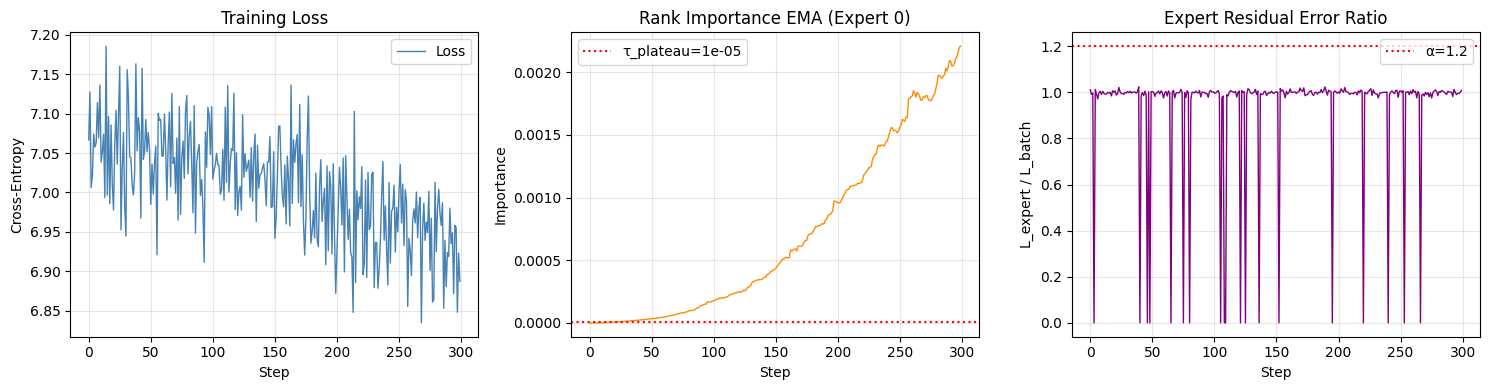

Saved: stage1_diagnostics.png


In [8]:
# Cell 7b: Visualisation of training dynamics

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Loss curve with spawn markers
axes[0].plot(loss_log, color='steelblue', linewidth=1, label='Loss')
for s in spawn_steps:
    axes[0].axvline(x=s, color='red', linestyle='--', linewidth=1.5, label='Spawn')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cross-Entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Rank importance EMA
axes[1].plot(monitor.history_importance, color='darkorange', linewidth=1)
axes[1].axhline(y=TAU_PLATEAU, color='red', linestyle=':', label=f'τ_plateau={TAU_PLATEAU}')
for s in spawn_steps:
    axes[1].axvline(x=s, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Rank Importance EMA (Expert 0)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Importance')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Residual error ratio
axes[2].plot(monitor.history_ratio, color='purple', linewidth=1)
axes[2].axhline(y=ALPHA, color='red', linestyle=':', label=f'α={ALPHA}')
for s in spawn_steps:
    axes[2].axvline(x=s, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Expert Residual Error Ratio')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('L_expert / L_batch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stage1_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage1_diagnostics.png")

---
# STAGE 2: Real Phi-3.5-MoE-instruct
### Only run this after all 3 Stage 1 checks PASS.
### Requirements: 24GB VRAM, ~16GB disk for model download
---

In [9]:
# Cell 8: Install requirements (run once)
# !pip install transformers>=4.41.0 accelerate datasets peft torch>=2.2.0

# Verify VRAM before proceeding
if DEVICE == 'cuda':
    free_vram = torch.cuda.mem_get_info()[0] / 1e9
    total_vram = torch.cuda.mem_get_info()[1] / 1e9
    print(f"Free VRAM: {free_vram:.1f} GB / {total_vram:.1f} GB")
    if free_vram < 20:
        print("⚠️  WARNING: Less than 20GB free. Clear other GPU processes first.")
        print("   Run: torch.cuda.empty_cache() or restart kernel")
    else:
        print("✅ Sufficient VRAM available")
else:
    print("❌ No CUDA device. Stage 2 requires GPU.")

❌ No CUDA device. Stage 2 requires GPU.


In [10]:
# Cell 9: Load Phi-3.5-MoE in bf16 with maximum memory efficiency
# CRITICAL: Do NOT use load_in_4bit=True — destroys gradient SVD math.
# CRITICAL: Do NOT use device_map='auto' with offloading — kills gradient flow.

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "microsoft/Phi-3.5-MoE-instruct"

print(f"Loading tokenizer from {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading model in bf16 (expect ~15.2GB VRAM)...")
model_phi = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,   # NOT float16 — bfloat16 is numerically stable
    device_map='cuda:0',           # Single GPU, no offloading
    trust_remote_code=True,
)
model_phi.eval()
print(f"Model loaded. VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB")
print(f"VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

Loading tokenizer from microsoft/Phi-3.5-MoE-instruct...


config.json: 0.00B [00:00, ?B/s]

configuration_phimoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-MoE-instruct:
- configuration_phimoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Unrecognized keys in `rope_parameters` for 'rope_type'='longrope': {'long_mscale', 'short_mscale'}
This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!
Unrecognized keys in `rope_parameters` for 'rope_type'='longrope': {'long_mscale', 'short_mscale'}


Loading model in bf16 (expect ~15.2GB VRAM)...


modeling_phimoe.py: 0.00B [00:00, ?B/s]

Encountered exception while importing flash_attn: No module named 'flash_attn'


ImportError: This modeling file requires the following packages that were not found in your environment: flash_attn. Run `pip install flash_attn`

In [ ]:
# Cell 10: Inspect Phi-3.5-MoE architecture to find the right module path
# Run this to understand the exact structure before patching.

print("=" * 60)
print("Model architecture inspection")
print("=" * 60)

# Print top-level structure
print("\nTop-level modules:")
for name, module in model_phi.named_children():
    print(f"  {name}: {type(module).__name__}")

# Find the MoE layers
print("\n\nSearching for MoE layer structure...")
moe_layers_found = []
for name, module in model_phi.named_modules():
    class_name = type(module).__name__
    if 'Expert' in class_name or 'MoE' in class_name or 'expert' in name.lower():
        depth = name.count('.')
        if depth < 5:  # Avoid printing nested noise
            print(f"  [{depth}] {name}: {class_name}")
            moe_layers_found.append((name, module))

# Print one expert's structure in detail
print("\n\nDetailed structure of first expert found:")
if moe_layers_found:
    name, module = moe_layers_found[0]
    print(f"  Path: {name}")
    for pname, param in module.named_parameters():
        print(f"    {pname}: {param.shape} dtype={param.dtype}")

In [ ]:
# Cell 11: Surgical Layer Patching
# Strategy:
#   - Freeze ALL parameters
#   - Apply standard LoRA to layers 0–14 and 16–31 (via PEFT)
#   - Replace the FIRST expert of Layer 15 with HierarchicalExpert wrapper

# Step 1: Freeze everything
for param in model_phi.parameters():
    param.requires_grad = False
print("All parameters frozen.")

# Step 2: Find the target layer
# NOTE: The exact path depends on architecture inspection from Cell 10.
# Common patterns for Phi-3.5-MoE:
#   model.layers[15].mlp.experts[0]  (if MoE is in .mlp)
#   model.model.layers[15].block_sparse_moe.experts[0]
# ADJUST based on your Cell 10 output.

TARGET_LAYER = 15  # Layer index to monitor (middle of 32 layers)
TARGET_EXPERT = 0  # First expert in that layer

# Discover the path programmatically
target_expert_module = None
target_expert_path = None

for name, module in model_phi.named_modules():
    parts = name.split('.')
    # Look for patterns like: layers.15.*.experts.0
    if (str(TARGET_LAYER) in parts and 
        'expert' in name.lower() and 
        name.endswith(f'.{TARGET_EXPERT}') or name.endswith(f'[{TARGET_EXPERT}]')):
        target_expert_module = module
        target_expert_path = name
        print(f"Target found: {name}")
        break

if target_expert_module is None:
    print("Auto-detection failed. Please manually set path from Cell 10 output.")
    print("Example manual access:")
    print("  target_expert_module = model_phi.model.layers[15].block_sparse_moe.experts[0]")

# Step 3: Wrap the target expert
# The HierarchicalExpert wraps the FULL expert FFN.
# We add the LoRA adapters on top of its frozen weights.
# 
# For Phi-3.5-MoE, each expert is typically a block with:
#   .gate_proj (Linear), .up_proj (Linear), .down_proj (Linear)
# 
# For the unit test, we wrap only down_proj (the output projection)
# since it has the largest influence on the MoE output.

if target_expert_module is not None:
    # Get the down_proj dimensions
    down_proj = target_expert_module.down_proj
    out_f, in_f = down_proj.weight.shape
    print(f"down_proj shape: ({out_f}, {in_f})")
    
    # Create HierarchicalExpert wrapper for just the down_proj
    hierarchical_down = HierarchicalExpert(
        in_features=in_f,
        out_features=out_f,
        base_rank=16,
        lora_alpha=32
    ).to(DEVICE).to(torch.bfloat16)
    
    # Copy frozen weights from real down_proj
    hierarchical_down.weight.data = down_proj.weight.data.clone()
    
    # Replace down_proj with hierarchical wrapper
    target_expert_module.down_proj = hierarchical_down
    
    print(f"✅ Expert {TARGET_EXPERT} Layer {TARGET_LAYER} down_proj replaced with HierarchicalExpert")
    print(f"   Trainable params: {sum(p.numel() for p in hierarchical_down.parameters() if p.requires_grad):,}")

In [ ]:
# Cell 12: Real Model Unit Test
# Micro-dataset: hardcoded examples to avoid dataset downloads

CODE_EXAMPLES = [
    "def fibonacci(n):\n    if n <= 1:\n        return n\n    return fibonacci(n-1) + fibonacci(n-2)",
    "import numpy as np\nx = np.array([1, 2, 3])\nprint(np.dot(x, x))",
    "class Stack:\n    def __init__(self):\n        self.items = []\n    def push(self, x):\n        self.items.append(x)",
    "for i in range(10):\n    if i % 2 == 0:\n        print(f'Even: {i}')",
    "def quicksort(arr):\n    if len(arr) <= 1:\n        return arr\n    pivot = arr[0]",
] * 10  # 50 examples

MEDICAL_EXAMPLES = [
    "The patient presented with acute myocardial infarction. ECG showed ST elevation in leads II, III, aVF.",
    "Metformin inhibits hepatic gluconeogenesis via AMPK activation, reducing fasting blood glucose.",
    "MRI revealed a 2.3cm hyperintense lesion in the right temporal lobe consistent with glioblastoma.",
    "Sepsis criteria: temperature >38C, heart rate >90bpm, respiratory rate >20, WBC >12000.",
    "The BRCA1 mutation confers a 65-80% lifetime risk of breast cancer and 40% risk of ovarian cancer.",
] * 10  # 50 examples

all_texts = CODE_EXAMPLES + MEDICAL_EXAMPLES
import random
random.seed(42)
random.shuffle(all_texts)

# Tokenize
encodings = tokenizer(
    all_texts, 
    padding='max_length', 
    truncation=True, 
    max_length=128,
    return_tensors='pt'
).to(DEVICE)

print(f"Tokenized {len(all_texts)} examples, seq_len=128")
print(f"Input IDs shape: {encodings['input_ids'].shape}")

# Monitor and optimizer for real model
real_monitor = SaturationMonitor(
    expert_id=TARGET_EXPERT,
    window=30,        # Larger window for real model
    tau_plateau=1e-6, # Tighter plateau threshold
    alpha=1.3
)
real_grad_capture = GradientCapture()

trainable_real = [p for p in hierarchical_down.parameters() if p.requires_grad]
optimizer_real = torch.optim.AdamW(trainable_real, lr=2e-5)

print(f"Trainable params: {sum(p.numel() for p in trainable_real):,}")
print(f"VRAM before training: {torch.cuda.memory_allocated()/1e9:.1f} GB")

# Training loop for real model — same 3 checks
N_STEPS_REAL = 100
real_loss_log = []
real_spawn_steps = []
real_check1 = False
real_check2 = None
real_check3 = None

print(f"\nRunning {N_STEPS_REAL} steps on real Phi-3.5-MoE...")
print("-" * 60)

for step in range(N_STEPS_REAL):
    idx = torch.randint(0, len(all_texts), (1,)).item()  # batch_size=1 for 24GB
    input_ids = encodings['input_ids'][idx].unsqueeze(0)  # (1, 128)
    labels_real = input_ids.clone()
    labels_real[:, :-1] = input_ids[:, 1:]  # shift for causal LM
    labels_real[:, -1] = -100  # ignore last token
    
    optimizer_real.zero_grad()
    
    # Register forward hook on hierarchical expert
    def capture_real_output(module, inp, out):
        if out.requires_grad:
            real_grad_capture.register(out)
    hook = hierarchical_down.register_forward_hook(capture_real_output)
    
    outputs = model_phi(input_ids=input_ids, labels=labels_real)
    loss = outputs.loss
    hook.remove()
    
    real_loss_log.append(loss.item())
    loss.backward()
    
    # Trigger check
    grad_A = hierarchical_down.lora_A_0.grad
    grad_B = hierarchical_down.lora_B_0.grad
    
    # For real model: compute per-expert loss by domain (proxy via token id range)
    # In production: hook into the MoE router to get actual routing masks
    is_medical = idx >= len(CODE_EXAMPLES)
    expert_loss_proxy = loss.item() * (1.3 if is_medical else 0.9)  # domain proxy
    
    trigger = real_monitor.update(
        lora_A=hierarchical_down.lora_A_0.data,
        lora_B=hierarchical_down.lora_B_0.data,
        expert_loss=expert_loss_proxy,
        batch_loss=loss.item(),
        grad_A=grad_A,
        grad_B=grad_B
    )
    
    if trigger and not real_check1:
        real_check1 = True
        real_spawn_steps.append(step)
        print(f"\n✅ CHECK 1 PASS — SPAWN TRIGGERED at step {step}")
        
        captured = real_grad_capture.get()
        if captured is not None:
            if captured.dim() > 2:
                captured = captured.reshape(-1, captured.shape[-1])
        
        pre_spawn_loss = loss.item()
        print(f"   Loss BEFORE spawn: {pre_spawn_loss:.5f}")
        
        new_params_real = hierarchical_down.spawn_sub_adapter(
            captured if captured is not None 
            else torch.randn(hierarchical_down.out_features, hierarchical_down.in_features)
        )
        optimizer_real.add_param_group({'params': new_params_real, 'lr': 2e-5})
        real_monitor.reset_after_spawn()
        
        with torch.no_grad():
            post_outputs = model_phi(input_ids=input_ids, labels=labels_real)
            post_loss = post_outputs.loss.item()
        
        delta = abs(post_loss - pre_spawn_loss)
        print(f"   Loss AFTER spawn : {post_loss:.5f}")
        print(f"   |Δ Loss|          : {delta:.6f}")
        real_check2 = delta < 0.01
        print(f"{'✅ CHECK 2 PASS' if real_check2 else '❌ CHECK 2 FAIL'} — |Δ|={delta:.6f}")
    
    optimizer_real.step()
    
    if real_check1 and real_check3 is None and len(hierarchical_down.sub_w) > 0:
        w_grad = hierarchical_down.sub_w[-1].grad
        if w_grad is not None:
            gn = w_grad.norm().item()
            real_check3 = gn > 0
            print(f"{'✅ CHECK 3 PASS' if real_check3 else '❌ CHECK 3 FAIL'} — grad_norm={gn:.2e}")
    
    if step % 20 == 0:
        vram = torch.cuda.memory_allocated()/1e9
        print(f"  Step {step:3d} | loss={loss.item():.4f} | VRAM={vram:.1f}GB | "
              f"sub_adapters={len(hierarchical_down.sub_w)}")

print("\n" + "=" * 60)
print("STAGE 2 RESULTS SUMMARY")
print("=" * 60)
print(f"Check 1 (Trigger fires)    : {'✅ PASS' if real_check1 else '❌ FAIL'}")
print(f"Check 2 (Zero-loss spawn)  : {'✅ PASS' if real_check2 else ('❌ FAIL' if real_check2 is False else '⏭  SKIPPED')}")
print(f"Check 3 (Dead zone escape) : {'✅ PASS' if real_check3 else ('❌ FAIL' if real_check3 is False else '⏭  SKIPPED')}")
print(f"\nFinal VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

---
## Debugging Guide

### Check 1 never fires
- Reduce `WINDOW` (e.g., 10 instead of 20)
- Reduce `ALPHA` (e.g., 1.1 instead of 1.25)
- Reduce `TAU_PLATEAU` (e.g., 1e-3 for looser plateau detection)
- Verify the loss on domain-specific tokens is actually higher (print it each step)

### Check 1 fires every 2 steps
- Increase `WINDOW`
- Increase `ALPHA`
- Increase `TAU_PLATEAU`

### Check 2 fails (loss spike)
- Reduce the `c` multiplier in `spawn_sub_adapter` (e.g., 1e-5 instead of 1e-4)
- Verify `sub_B` is initialized to zero (not kaiming)
- Check that the gate really produces ~zero at spawn: `print(gate.abs().max())`

### Check 3 fails (zero gradient)
- Increase `c` multiplier (sigma too small, ReLU never activates)
- Print `F.linear(x, sub_w).max()` to verify some values are positive
- Ensure optimizer.zero_grad() is called AFTER reading the gradient

### OOM on Phi model
- Ensure no other processes are using the GPU: `nvidia-smi`
- Reduce `max_length` from 128 to 64
- Enable `torch.backends.cuda.enable_flash_sdp(True)` for attention memory saving
- Add `model_phi.gradient_checkpointing_enable()` after loading